<a href="https://colab.research.google.com/github/hieuvu-0111/Lotka-Volterra-Model-Visualization/blob/main/Lotka_Volterra_Model_Visualization_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

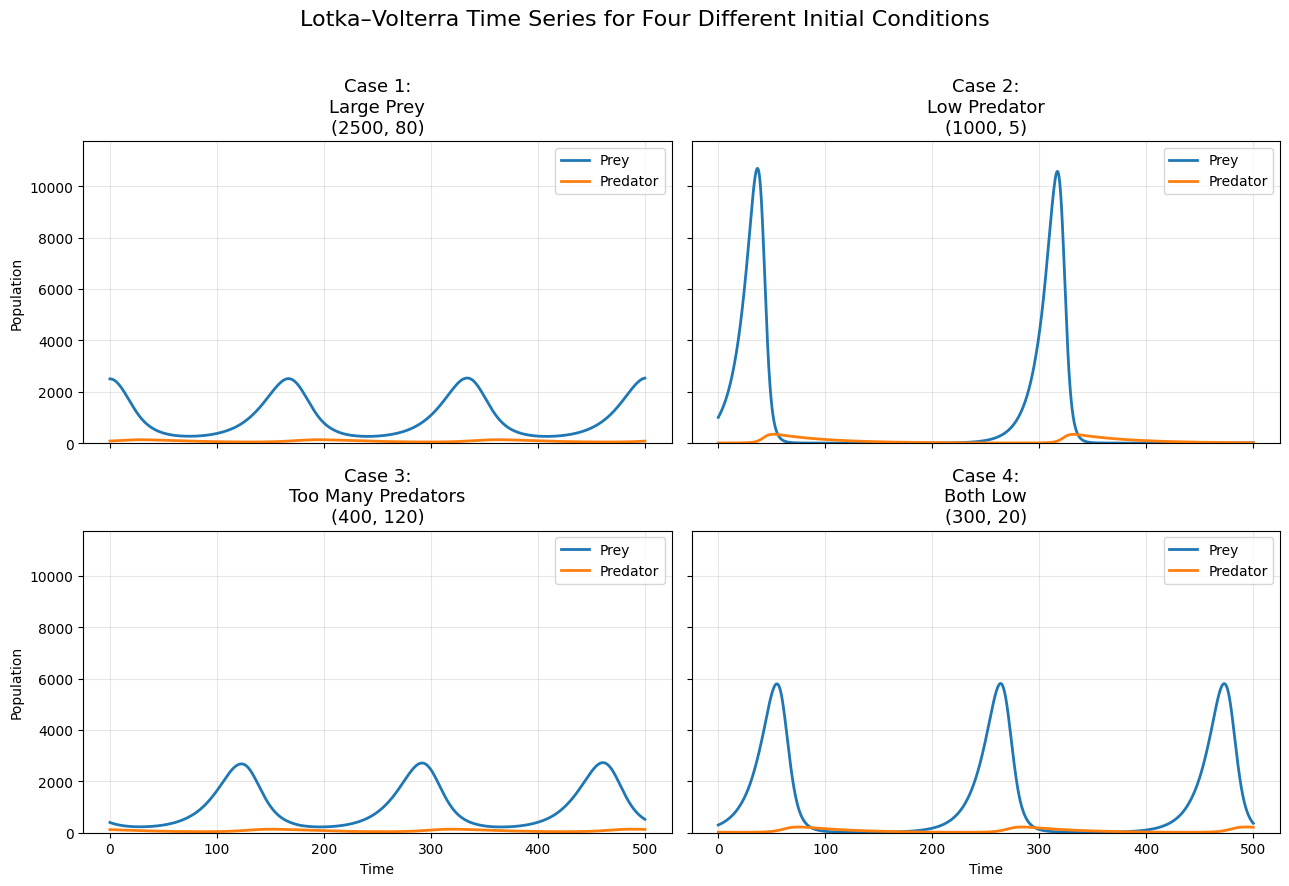

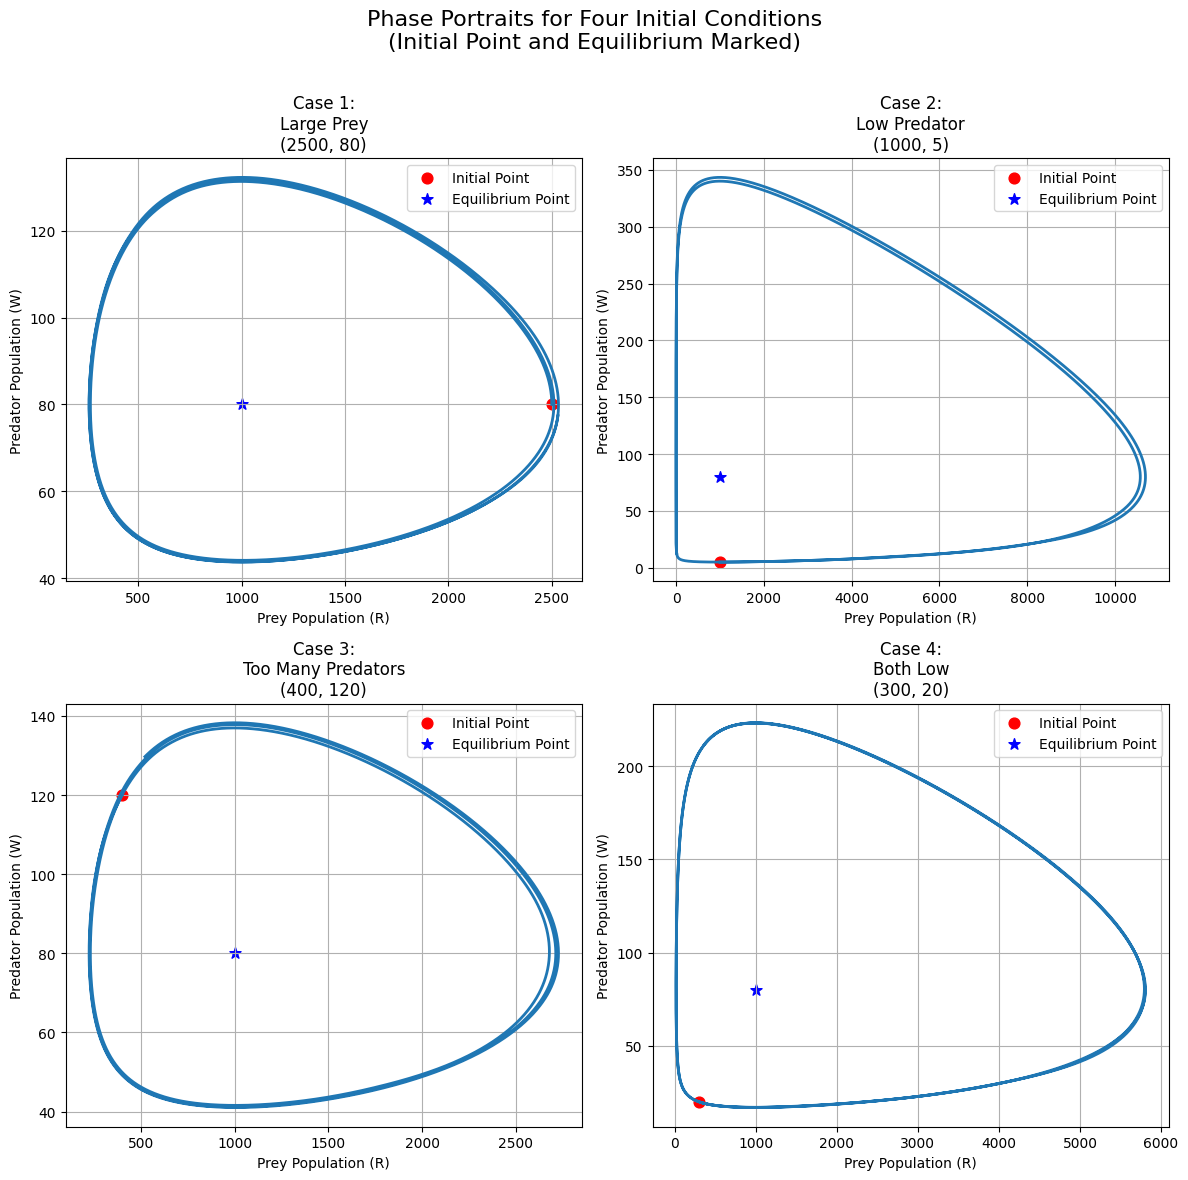

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Visualize the model with 4 different initial conditions

# Lotka–Volterra System
def lotka_volterra(t, z, a, b, c, d):
    x, y = z
    dxdt = a*x - b*x*y
    dydt = -c*y + d*x*y
    return [dxdt, dydt]


# Parameters (same for all)
a = 0.08       # prey growth rate
b = 0.001      # predation rate
c = 0.02       # predator natural death rate
d = 0.00002    # predator growth per prey eaten


# Four Initial Condition Scenarios
cases = [
    ([2500, 80],  "Case 1:\nLarge Prey\n(2500, 80)"),
    ([1000, 5],   "Case 2:\nLow Predator\n(1000, 5)"),
    ([400, 120],  "Case 3:\nToo Many Predators\n(400, 120)"),
    ([300, 20],   "Case 4:\nBoth Low\n(300, 20)")
]

# Time span for all cases
t_span = (0, 500)
t_eval = np.linspace(t_span[0], t_span[1], 6000)


# Solve ODE for all cases
solutions = []
for ic, title in cases:
    sol = solve_ivp(lotka_volterra, t_span, ic, t_eval=t_eval, args=(a, b, c, d))
    solutions.append((sol.y[0], sol.y[1], sol.t, ic, title))


# Time-series plot

# Find global max population across all solutions for consistent y-scale
global_max = max(max(x.max(), y.max()) for (x, y, _, _, _) in solutions)
y_limit = global_max * 1.1

fig, axs = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
axs = axs.flatten()

for ax, (x, y, t, ic, title) in zip(axs, solutions):
    ax.plot(t, x, label="Prey", linewidth=2)
    ax.plot(t, y, label="Predator", linewidth=2)

    ax.set_title(title, fontsize=13)
    ax.set_ylim(0, y_limit)

    if ax in [axs[0], axs[2]]:  # left column
        ax.set_ylabel("Population")
    if ax in [axs[2], axs[3]]:  # bottom row
        ax.set_xlabel("Time")

    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle("Lotka–Volterra Time Series for Four Different Initial Conditions", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# Phase portrait with initial points + equilibrium point

# Compute equilibrium point
x_eq = c / d          # prey equilibrium
y_eq = a / b          # predator equilibrium

fig, axs = plt.subplots(2, 2, figsize=(12, 12))
axs = axs.flatten()

for ax, (x, y, t, ic, title) in zip(axs, solutions):
    ax.plot(x, y, linewidth=2)

    # Mark the initial point
    ax.scatter(ic[0], ic[1], s=60, color='red', label="Initial Point")

    # Mark the equilibrium point
    ax.scatter(x_eq, y_eq, s=70, color='blue', marker='*', label="Equilibrium Point")

    ax.set_xlabel("Prey Population (R)")
    ax.set_ylabel("Predator Population (W)")
    ax.set_title(title)
    ax.grid(True)
    ax.legend()

plt.suptitle("Phase Portraits for Four Initial Conditions\n(Initial Point and Equilibrium Marked)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
